In [1]:
import torch
import sys
sys.path.insert(0, '../')
sys.path.insert(0, '../../')

from pathlib import Path

from effnet_plagiarism import ImageTransformPlagiarismPredictor
from src.dataset import ImageTransformer, TransformTokenizer, TRANSFORM_TOKENS
from PIL import Image
from omegaconf import OmegaConf
from torchvision import transforms
import os

%load_ext autoreload
%autoreload 2

In [2]:
# !pip install efficientnet-pytorch
# !pip install numpy==1.23.5

In [4]:
config = OmegaConf.load('../configs/train_config_plagiarism.yaml')

model = ImageTransformPlagiarismPredictor(config.model)

checkpoint_path = "../../checkpoints/plagiarism_tune/checkpoint_epoch_15.pth"

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to('cpu')
model.eval()
print('ready')

Loaded pretrained weights for efficientnet-b3
ready


```
python export_plagiarism_weights.py \
    --checkpoint ../../checkpoints/plagiarism_tune/checkpoint_epoch_15.pth \
    --output_dir ../../checkpoints/plagiarism_tune/ \
    --verify
```

In [5]:
preprocess = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

['rotate_180']


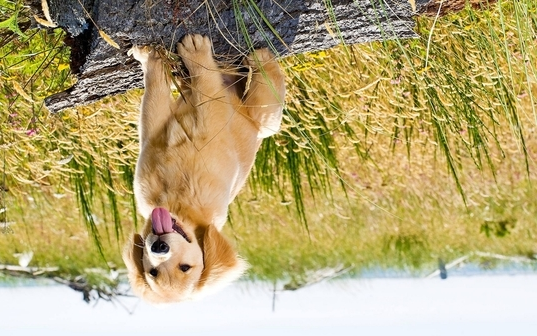

In [6]:
image_path_1 = '../../assets/dog.jpg'
image_path_2 = '../../assets/image.jpg'

image_1 = Image.open(image_path_1)
image_2 = Image.open(image_path_2)

it = ImageTransformer()
transformed_image_1, sequence_1 = it.transform(image_1, p=0.3)
print(sequence_1)
transformed_image_1

In [7]:
image_tensor_1 = preprocess(image_1).unsqueeze(0)
image_tensor_2 = preprocess(image_2).unsqueeze(0)
transformed_image_tensor = preprocess(transformed_image_1).unsqueeze(0)

generated = model.generate(image_tensor_1, transformed_image_tensor, max_new_tokens=10, do_sample=False) #, top_k=3)

print(generated)

tokenizer = TransformTokenizer()
tokens = tokenizer.decode(generated[0][0], skip_special_tokens=True)
print(f"Predicted: {tokens}")
print(f"Target: {sequence_1}")

(tensor([[1, 6, 2, 0, 0, 0, 0, 0, 0, 0, 0]]), tensor([1.]))
Predicted: ['rotate_180']
Target: ['rotate_180']


In [9]:
logits = model(image_tensor_1, transformed_image_tensor, torch.tensor([[1]]))
logits = logits[0][0]
logits[:, model.pad_token_id] = -float('inf')
logits[:, model.bos_token_id] = -float('inf')
probs = torch.exp(logits) / torch.exp(logits).sum(dim=-1, keepdim=True)
p_eos = probs[:, 2]
similarities = 1.0 - p_eos
similarities.item()

0.9999876618385315